In [1]:
from earthdaily.earthone.catalog import Product, Image, ImageCollection, properties as p
from earthdaily.earthone.geo import DLTile, AOI

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from shapely import affinity
from scipy.signal import convolve

In [3]:
def get_kernel(size, num_conv):
    assert type(num_conv) == int, "num_conv must be an integer"
    k0 = np.ones((size, size))
    k = k0
    for i in range(num_conv):
        if i > 3:
            k = convolve(k, k0, mode="same")
        else:
            k = convolve(k, k0)
    k /= np.sum(k)

    return k.astype(np.float32)

def smoothed_dot_prod(z1, z2, k, real=False):
    """
    For each pixel compute the dot product of the two
    scenes within the weighted neighborhood given by k

    Parameters
    ----------
    z1 : array
        First complex scene
    z2 : array
        Second complex scene
    k : array
        2D kernel for smoothing

    Returns
    -------
    zz : array
        Smoothed dot product.
    """
    if not real:
        return convolve(z1 * np.conj(z2), k, mode="same")
    else:
        return convolve(np.abs(z1) * np.abs(z2), k, mode="same") 

In [4]:
k = get_kernel(3, 5)
k

array([[6.8113579e-05, 2.3839751e-04, 5.6761311e-04, 1.0217036e-03,
        1.4303850e-03, 1.6006690e-03, 1.4303850e-03, 1.0217036e-03,
        5.6761311e-04, 2.3839751e-04, 6.8113579e-05],
       [2.3839751e-04, 8.3439128e-04, 1.9866459e-03, 3.5759627e-03,
        5.0063478e-03, 5.6023416e-03, 5.0063478e-03, 3.5759627e-03,
        1.9866459e-03, 8.3439128e-04, 2.3839751e-04],
       [5.6761311e-04, 1.9866459e-03, 4.7301096e-03, 8.5141966e-03,
        1.1919876e-02, 1.3338909e-02, 1.1919876e-02, 8.5141966e-03,
        4.7301096e-03, 1.9866459e-03, 5.6761311e-04],
       [1.0217036e-03, 3.5759627e-03, 8.5141966e-03, 1.5325555e-02,
        2.1455776e-02, 2.4010036e-02, 2.1455776e-02, 1.5325555e-02,
        8.5141966e-03, 3.5759627e-03, 1.0217036e-03],
       [1.4303850e-03, 5.0063478e-03, 1.1919876e-02, 2.1455776e-02,
        3.0038087e-02, 3.3614051e-02, 3.0038087e-02, 2.1455776e-02,
        1.1919876e-02, 5.0063478e-03, 1.4303850e-03],
       [1.6006690e-03, 5.6023416e-03, 1.3338909e-0

In [5]:
# Very simple filtering - as we know there are only 2 images currently in the beta product
aoi = AOI(
    bounds = [40.62, 13.56, 40.72, 13.64],
    resolution=10.0,
    crs="EPSG:32637",
    align_pixels=True
)
coll = Product.get("nasa:nisar:gslc:beta-v1").images().intersects(aoi).collect()
aoi

AOI(geometry=None,
    resolution=10.0,
    crs='EPSG:32637',
    align_pixels=True,
    bounds=(40.62, 13.56, 40.72, 13.64),
    bounds_crs='EPSG:4326',
    shape=None,
    all_touched=False)

In [6]:
coll

ImageCollection of 2 images
  * Dates: Nov 22, 2025 to Dec 04, 2025
  * Products: nasa:nisar:gslc:beta-v1: 2

In [7]:
scale = coll[0].scaling_parameters(["real", "imag"], data_type="Float32")

In [8]:
arr, info = coll.stack(["real", "imag"], geocontext=aoi, scaling=scale[0], raster_info=True)

In [9]:
[x["geoTransform"] for x in info]

[[675230.0, 10.0, 0.0, 1508580.0, 0.0, -10.0],
 [675230.0, 10.0, 0.0, 1508580.0, 0.0, -10.0]]

In [10]:
z = np.zeros((arr.shape[0], arr.shape[2], arr.shape[3]), dtype=np.complex64)
for ii in range(arr.shape[0]):
    z[ii] = (arr[ii, 0] + 1j * arr[ii, 1])
arr = None

In [11]:
z1 = z[0]
z2 = z[1]
num = smoothed_dot_prod(z1, z2, k)
dnm = np.sqrt(smoothed_dot_prod(z1, z1, k, real=True) * smoothed_dot_prod(z2, z2, k, real=True))
mask = dnm == 0
mask = (z1 != 0.) & (z2 != 0.)
dnm[~mask] = 1
num[~mask] = 0
ifg = num / dnm

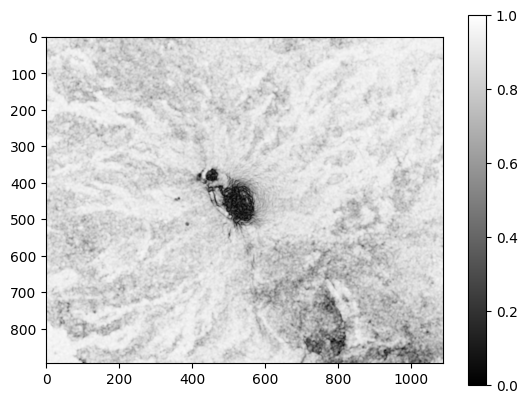

In [12]:
# Plot coherence
plt.figure(); plt.imshow(np.abs(ifg), vmin=0, vmax=1.0, cmap="gray", interpolation=None); plt.colorbar(); plt.show()

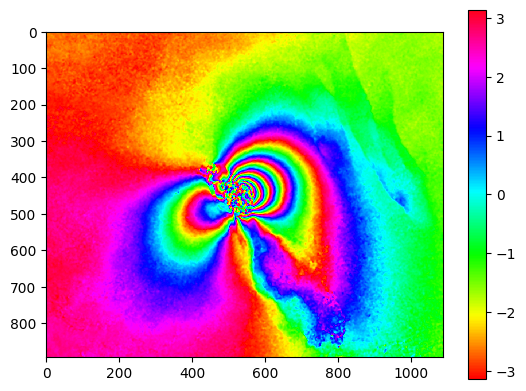

In [13]:
# Plot phase
plt.figure(); plt.imshow(np.angle(ifg), vmin=-np.pi, vmax=np.pi, cmap="hsv", interpolation="none"); plt.colorbar(); plt.show()